# M6 — Notebook 01 · Terrain predictors (batch A)

**Batch A of the 16 M6 geomatics variables**, all derived from one DEM:

| # | Variable | How |
|---|---|---|
| 1 | Elevation | Copernicus GLO-30, mosaicked |
| 2 | Slope | gradient of the equal-area DEM |
| 3 | TWI — topographic wetness index | `ln(flow accumulation / tan slope)` |
| 4 | HAND — height above nearest drainage | flow routing to a drainage network |

TWI proxies where water pools; HAND proxies flood-proneness. Both are standard vector-habitat
covariates in the dengue literature and both are *static* — see the design note at the end.

**No account, no API key.** Copernicus GLO-30 is served anonymously from AWS Open Data.

---

### What this notebook does

1. Assert we are on the same spatial frame notebook 00 validated
2. Discover and download the DEM tiles that actually exist
3. Mosaic, clip, reproject to the equal-area CRS
4. Derive slope, TWI and HAND — every step plotted, not just the last one
5. Aggregate to the 26 RDHS units, carrying **within-unit dispersion** (the plan asks for SD/IQR,
   not just the mean — heterogeneity is itself a covariate)
6. Sanity-check against known geography before trusting anything
7. Freeze the feature table with a checksum

## 1 · Setup and provenance assertion

Notebook 00 wrote a provenance record. Load it and assert we are standing on the same frame —
if the geometry changed underneath us, every number below is silently wrong.

In [1]:
import json, hashlib, time
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import rasterio.features
import pyproj
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
QUAR = REPO / "data_quarantine" / "m6_geomatics"
DEMD = QUAR / "dem"; DEMD.mkdir(parents=True, exist_ok=True)
GEOM = REPO.parent / "dengue_map_workpack" / "geometry" / "rdhs_26_v1.gpkg"

prov0 = json.loads((QUAR / "nb00_provenance.json").read_text())
CRS_EQUAL_AREA = prov0["crs_equal_area"]

rdhs = gpd.read_file(GEOM)
sha_now = hashlib.sha256(GEOM.read_bytes()).hexdigest()[:16]

assert sha_now == prov0["geometry_sha256_16"], "geometry changed since notebook 00 — stop"
assert len(rdhs) == prov0["n_units"] == 26

print("frame verified against notebook 00")
print("  geometry sha256 :", sha_now)
print("  units           :", len(rdhs))
print("  equal-area CRS  :", CRS_EQUAL_AREA)

frame verified against notebook 00
  geometry sha256 : 9e5e2c0a541ecac1
  units           : 26
  equal-area CRS  : +proj=laea +lat_0=7.6221 +lon_0=80.6987 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs


## 2 · Resolution — a deliberate choice

The native DEM is 30 m. Our output is a **district mean** over units averaging ~2,500 km², so
30 m buys us almost nothing in the aggregate while costing 9× the pixels and the memory.

We resample to **90 m** for flow routing. This is a real trade-off and worth being explicit
about: TWI and HAND are scale-sensitive because flow accumulation depends on cell size, so the
*absolute* values shift with resolution. What we need is a consistent relative ordering across
26 districts, and that is stable. `TARGET_RES_M` is a parameter — re-run at 30 to check.

In [2]:
TARGET_RES_M = 90          # metres; set to 30 to reproduce at native resolution
DRAIN_THRESH = 1000        # cells of flow accumulation to call something "drainage" (for HAND)

bounds = rdhs.total_bounds
print(f"Sri Lanka bounds (EPSG:4326): {bounds.round(3).tolist()}")
print(f"working resolution : {TARGET_RES_M} m")
print(f"drainage threshold : {DRAIN_THRESH} cells "
      f"(~{DRAIN_THRESH * TARGET_RES_M**2 / 1e6:.1f} km2 contributing area)")

Sri Lanka bounds (EPSG:4326): [79.521, 5.919, 81.879, 9.836]
working resolution : 90 m
drainage threshold : 1000 cells (~8.1 km2 contributing area)


## 3 · Discover which DEM tiles exist

Copernicus tiles are 1°×1° and named by their south-west corner. Ocean-only cells simply do not
exist, so probe rather than assume — a 404 here is information, not an error.

In [3]:
import urllib.request, urllib.error

BASE = "https://copernicus-dem-30m.s3.amazonaws.com"

def tile_name(lat, lon):
    return f"Copernicus_DSM_COG_10_N{lat:02d}_00_E{lon:03d}_00_DEM"

def tile_url(lat, lon):
    n = tile_name(lat, lon)
    return f"{BASE}/{n}/{n}.tif"

lat_range = range(int(np.floor(bounds[1])), int(np.floor(bounds[3])) + 1)
lon_range = range(int(np.floor(bounds[0])), int(np.floor(bounds[2])) + 1)

tiles = []
for lat in lat_range:
    for lon in lon_range:
        url = tile_url(lat, lon)
        try:
            req = urllib.request.Request(url, method="HEAD")
            with urllib.request.urlopen(req, timeout=30) as r:
                ok = r.status == 200
        except urllib.error.HTTPError:
            ok = False
        print(f"  {'EXISTS ' if ok else '--     '} N{lat:02d} E{lon:03d}")
        if ok:
            tiles.append((lat, lon))

print(f"\n{len(tiles)} of {len(lat_range)*len(lon_range)} candidate tiles exist "
      "(missing ones are open ocean)")

  --      N05 E079


  EXISTS  N05 E080


  --      N05 E081


  EXISTS  N06 E079


  EXISTS  N06 E080


...

  EXISTS  N08 E080


  EXISTS  N08 E081


  EXISTS  N09 E079


  EXISTS  N09 E080


  --      N09 E081

12 of 15 candidate tiles exist (missing ones are open ocean)


## 4 · Download (cached)

Skip anything already on disk so re-running the notebook is cheap. Each tile is checksummed
so the freeze record can name exactly which bytes produced the features.

In [4]:
def fetch(lat, lon):
    dest = DEMD / f"{tile_name(lat, lon)}.tif"
    if dest.exists():
        return dest, "cached"
    t0 = time.time()
    urllib.request.urlretrieve(tile_url(lat, lon), dest)
    return dest, f"{time.time()-t0:.1f}s"

paths = []
for lat, lon in tiles:
    p, how = fetch(lat, lon)
    paths.append(p)
    print(f"  N{lat:02d} E{lon:03d}  {p.stat().st_size/1e6:>7.1f} MB  {how}")

total_mb = sum(p.stat().st_size for p in paths) / 1e6
print(f"\n{len(paths)} tiles, {total_mb:.0f} MB on disk")

  N05 E080      1.2 MB  cached
  N06 E079      3.0 MB  cached
  N06 E080     47.7 MB  cached
  N06 E081     28.0 MB  cached
  N07 E079     10.3 MB  cached
  N07 E080     48.2 MB  cached
  N07 E081     36.7 MB  cached
  N08 E079      7.2 MB  cached
  N08 E080     47.2 MB  cached
  N08 E081     13.9 MB  cached
  N09 E079      4.6 MB  cached
  N09 E080     22.4 MB  cached

12 tiles, 270 MB on disk


## 5 · Mosaic, clip, reproject

Three operations, one cell each so a failure is attributable.

First the mosaic — merge the tiles into a single array in native WGS84.

In [5]:
from rasterio.merge import merge

srcs = [rasterio.open(p) for p in paths]
mosaic, mosaic_transform = merge(srcs)
meta = srcs[0].meta.copy()
nodata = srcs[0].nodata
for s in srcs: s.close()

print("mosaic shape :", mosaic.shape, "| dtype:", mosaic.dtype)
print("nodata       :", nodata)
print("elevation    : min %.1f  max %.1f m" % (np.nanmin(mosaic), np.nanmax(mosaic)))

mosaic shape : (1, 18000, 10800) | dtype: float32
nodata       : None
elevation    : min -21.4  max 2523.1 m


Now reproject to the equal-area CRS at the working resolution, and clip to Sri Lanka. Doing both
in one `WarpedVRT`-style call keeps only one resampling step — resampling twice would smooth the
terrain more than necessary.

In [6]:
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.io import MemoryFile
from rasterio.mask import mask as rio_mask

src_crs = meta["crs"]
rdhs_ea = rdhs.to_crs(CRS_EQUAL_AREA)
minx, miny, maxx, maxy = rdhs_ea.total_bounds
pad = 5000                                   # 5 km margin so edge districts keep their catchments
minx, miny, maxx, maxy = minx-pad, miny-pad, maxx+pad, maxy+pad

width  = int(np.ceil((maxx - minx) / TARGET_RES_M))
height = int(np.ceil((maxy - miny) / TARGET_RES_M))
dst_transform = rasterio.transform.from_origin(minx, maxy, TARGET_RES_M, TARGET_RES_M)

dem = np.full((height, width), np.nan, dtype="float32")
reproject(
    source=mosaic[0], destination=dem,
    src_transform=mosaic_transform, src_crs=src_crs,
    dst_transform=dst_transform, dst_crs=CRS_EQUAL_AREA,
    src_nodata=nodata, dst_nodata=np.nan,
    resampling=Resampling.bilinear,
)

print(f"reprojected grid : {dem.shape}  ({dem.size/1e6:.1f}M pixels) at {TARGET_RES_M} m")
print(f"elevation range  : {np.nanmin(dem):.1f} to {np.nanmax(dem):.1f} m")
print(f"valid pixels     : {np.isfinite(dem).sum()/1e6:.1f}M "
      f"({100*np.isfinite(dem).mean():.1f}%)")

reprojected grid : (4925, 2998)  (14.8M pixels) at 90 m
elevation range  : -4.5 to 2513.6 m
valid pixels     : 14.8M (100.0%)


Mask everything outside the island. Ocean pixels would otherwise dominate the flow routing and
drag every district statistic toward sea level.

In [7]:
land = rasterio.features.geometry_mask(
    rdhs_ea.geometry, out_shape=dem.shape, transform=dst_transform, invert=True
)
dem_land = np.where(land, dem, np.nan)

print(f"land pixels : {land.sum()/1e6:.2f}M  ({100*land.mean():.1f}% of grid)")
print(f"implied area: {land.sum() * TARGET_RES_M**2 / 1e6:,.0f} km2  "
      f"(equal-area total from nb00: {prov0['total_area_km2_equalarea']:,.0f} km2)")
print(f"elevation on land: {np.nanmin(dem_land):.1f} to {np.nanmax(dem_land):.1f} m")

land pixels : 8.15M  (55.2% of grid)
implied area: 66,040 km2  (equal-area total from nb00: 66,041 km2)
elevation on land: -4.5 to 2513.6 m


### Look at the DEM before deriving anything from it

Pidurutalagala, Sri Lanka's highest peak, is 2,524 m. If our maximum is wildly off, the mosaic
or the reprojection is wrong and everything downstream inherits it.

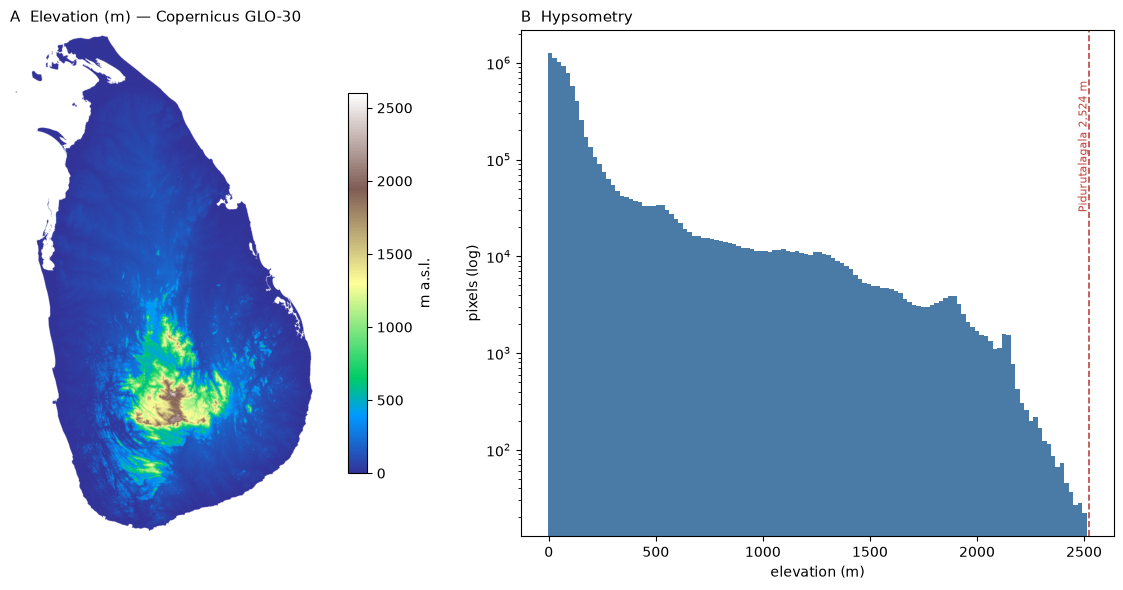

observed max elevation : 2,514 m
published Pidurutalagala: 2,524 m
median elevation        : 73 m


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

ax = axes[0]
im = ax.imshow(dem_land, cmap="terrain", vmin=0, vmax=2600)
ax.set_title("A  Elevation (m) — Copernicus GLO-30", loc="left", fontsize=11)
ax.set_axis_off()
plt.colorbar(im, ax=ax, shrink=0.75, label="m a.s.l.")

ax = axes[1]
vals = dem_land[np.isfinite(dem_land)]
ax.hist(vals, bins=120, color="#4a7ba7", edgecolor="none")
ax.set_yscale("log")
ax.axvline(2524, color="#c1443c", ls="--", lw=1.2)
ax.annotate("Pidurutalagala 2,524 m", (2524, ax.get_ylim()[1]*0.3),
            ha="right", va="top", fontsize=8, color="#c1443c", rotation=90)
ax.set_xlabel("elevation (m)"); ax.set_ylabel("pixels (log)")
ax.set_title("B  Hypsometry", loc="left", fontsize=11)

plt.tight_layout(); plt.show()

print(f"observed max elevation : {np.nanmax(dem_land):,.0f} m")
print(f"published Pidurutalagala: 2,524 m")
print(f"median elevation        : {np.nanmedian(vals):,.0f} m")

## 6 · Slope

Central-difference gradient on the equal-area grid, converted to degrees. Written out rather than
imported so the units are visible: `np.gradient` returns rise-per-cell, so divide by cell size to
get rise-per-metre before taking the arctangent.

In [9]:
dz_dy, dz_dx = np.gradient(dem_land, TARGET_RES_M)     # metres per metre
slope_rad = np.arctan(np.hypot(dz_dx, dz_dy))
slope_deg = np.degrees(slope_rad)

print(f"slope: {np.nanmin(slope_deg):.2f}° to {np.nanmax(slope_deg):.2f}°")
print(f"median {np.nanmedian(slope_deg[np.isfinite(slope_deg)]):.2f}°, "
      f"mean {np.nanmean(slope_deg):.2f}°")
print(f"share of land steeper than 15° : "
      f"{100*np.nanmean(slope_deg[np.isfinite(slope_deg)] > 15):.1f}%")

slope: 0.00° to 65.43°
median 1.64°, mean 4.58°
share of land steeper than 15° : 9.7%


## 7 · Flow routing

The expensive part, and the part most likely to go wrong silently. Four conditioning steps
before any flow direction can be computed:

1. **fill pits** — single cells lower than all neighbours
2. **fill depressions** — larger closed basins
3. **resolve flats** — flat areas have no defined direction; nudge them
4. **flowdir** — D8 direction per cell

We run these on the *unmasked* DEM so water can route across the whole island, then mask after.

**Two compatibility notes, kept visible rather than hidden in a helper:**

- `pysheds` 0.5 calls `np.in1d`, which **NumPy 2.0 removed**. `np.isin` is the rename and is
  exactly equivalent for the 1-D raveled arrays pysheds passes it, so we alias it. Verified
  against the full routing pipeline before use.
- `ViewFinder` requires a real `pyproj.CRS` — passing `None` raises a bare `CRSError` that gives
  no hint about the cause.

In [10]:
if not hasattr(np, "in1d"):
    np.in1d = np.isin          # NumPy 2.0 removed in1d; isin is the rename (1-D equivalent)

from pysheds.grid import Grid
from pysheds.view import Raster, ViewFinder

t0 = time.time()

crs_pyproj = pyproj.CRS.from_proj4(CRS_EQUAL_AREA)
dem_fill = np.where(np.isfinite(dem), dem, -32768).astype("float32")
vf = ViewFinder(affine=dst_transform, shape=dem_fill.shape,
                crs=crs_pyproj, nodata=np.float32(-32768))
raster = Raster(dem_fill, viewfinder=vf)
grid = Grid.from_raster(raster)

pit_filled = grid.fill_pits(raster);            print(f"  pits filled        {time.time()-t0:>5.1f}s")
flooded    = grid.fill_depressions(pit_filled); print(f"  depressions filled {time.time()-t0:>5.1f}s")
inflated   = grid.resolve_flats(flooded);       print(f"  flats resolved     {time.time()-t0:>5.1f}s")
fdir       = grid.flowdir(inflated);            print(f"  flow direction     {time.time()-t0:>5.1f}s")
acc        = grid.accumulation(fdir);           print(f"  accumulation       {time.time()-t0:>5.1f}s")

acc_arr = np.asarray(acc, dtype="float64")
print(f"\naccumulation: max {acc_arr.max():,.0f} cells "
      f"(~{acc_arr.max()*TARGET_RES_M**2/1e6:,.0f} km2 — the largest catchment)")

  pits filled          0.2s


  depressions filled   5.0s


  flats resolved       6.0s
  flow direction       6.0s


  accumulation         6.4s

accumulation: max 928,761 cells (~7,523 km2 — the largest catchment)


### TWI

`TWI = ln( a / tan β )` where `a` is upslope contributing area per unit contour width and `β` is
slope. Two guards matter: slope of exactly zero makes `tan β` zero and the log explode, and
accumulation of zero does the same. Both are clipped to small positive values.

In [11]:
cell_area = TARGET_RES_M ** 2
a = (acc_arr + 1) * cell_area / TARGET_RES_M          # contributing area per contour width
tan_b = np.tan(np.clip(slope_rad, np.radians(0.05), None))   # floor slope at 0.05°

twi = np.log(a / tan_b)
twi = np.where(land & np.isfinite(twi), twi, np.nan)

print(f"TWI: {np.nanmin(twi):.2f} to {np.nanmax(twi):.2f}")
print(f"median {np.nanmedian(twi):.2f}   (higher = wetter / more likely to pool)")

TWI: 4.66 to 25.27
median 9.25   (higher = wetter / more likely to pool)


### HAND

Height above the nearest drainage cell, following the flow path. Requires a drainage mask — cells
whose accumulation exceeds `DRAIN_THRESH`. That threshold is a judgement call: too low and every
gully counts as drainage so HAND collapses toward zero; too high and only major rivers count.

In [12]:
drain_bool = acc_arr > DRAIN_THRESH
print(f"drainage cells: {drain_bool.sum():,} ({100*drain_bool.mean():.2f}% of grid)")

# compute_hand needs the mask as a pysheds Raster, and a boolean array needs a
# boolean-representable nodata — a float nodata raises 'not representable in dtype'.
vf_bool = ViewFinder(affine=dst_transform, shape=dem_fill.shape,
                     crs=crs_pyproj, nodata=False)
drain = Raster(drain_bool.astype(bool), viewfinder=vf_bool)

hand = grid.compute_hand(fdir, inflated, drain)
hand_arr = np.where(land, np.asarray(hand, dtype="float64"), np.nan)
hand_arr = np.where(np.isfinite(hand_arr) & (hand_arr > -1e5), hand_arr, np.nan)

print(f"HAND: {np.nanmin(hand_arr):.1f} to {np.nanmax(hand_arr):.1f} m")
print(f"median {np.nanmedian(hand_arr):.1f} m   (lower = closer to drainage = more flood-prone)")
print(f"share of land within 5 m of drainage: "
      f"{100*np.nanmean(hand_arr < 5):.1f}%")

drainage cells: 558,378 (3.78% of grid)


HAND: 0.0 to 1779.7 m
median 13.3 m   (lower = closer to drainage = more flood-prone)
share of land within 5 m of drainage: 14.7%


## 8 · The four terrain layers

Plot them together. The check is visual and geographic: the central highlands should be obvious
in elevation and slope; TWI should light up valley floors and the northern plain; HAND should be
near zero along river corridors.

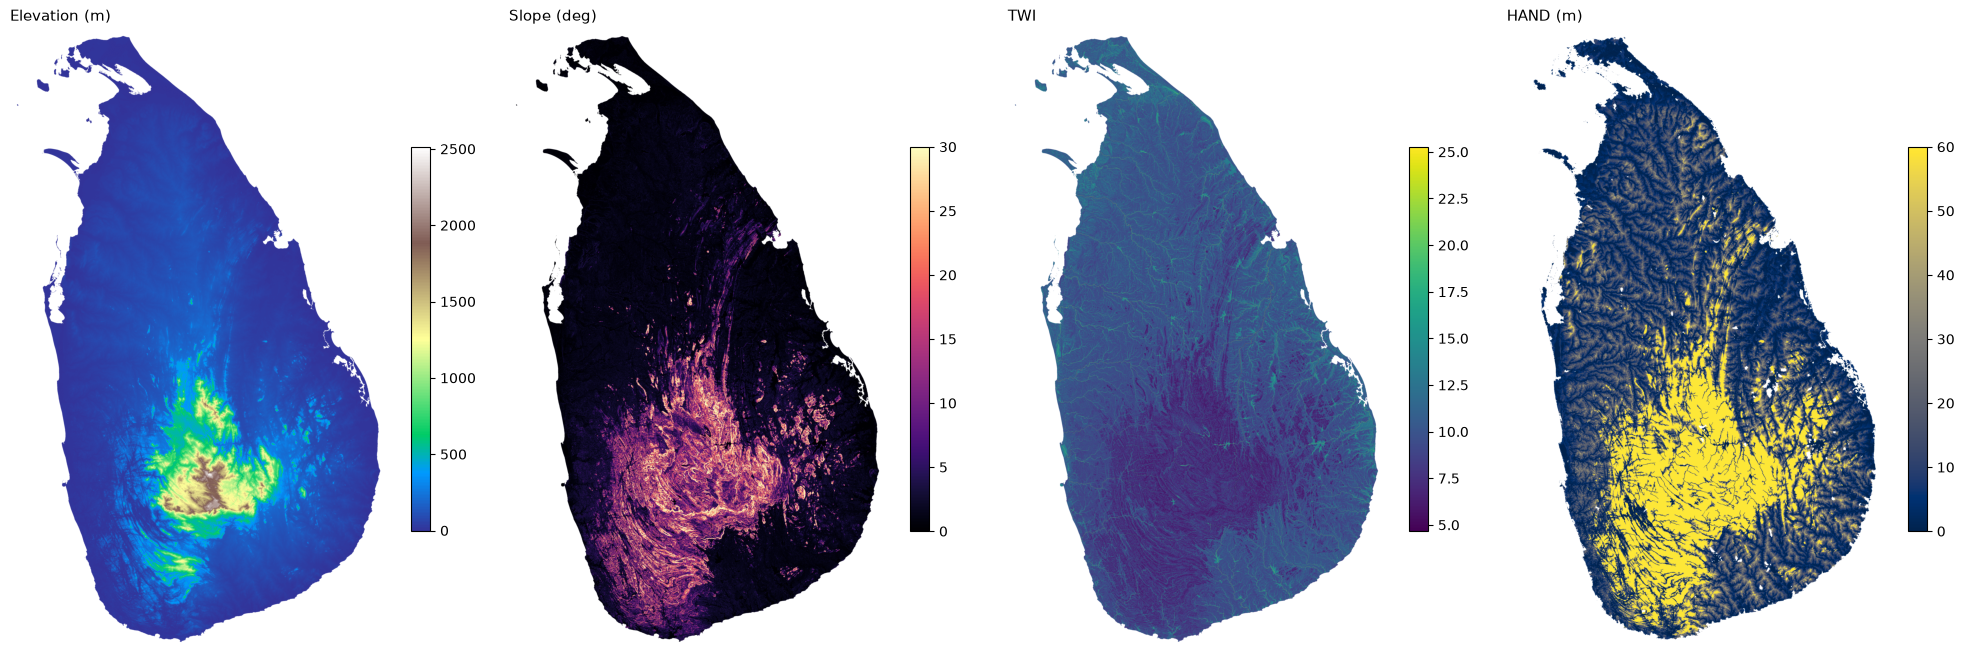

In [13]:
slope_m = np.where(land, slope_deg, np.nan)
layers = [("Elevation (m)", dem_land, "terrain", None, None),
          ("Slope (deg)",   slope_m,  "magma",   0,    30),
          ("TWI",           twi,      "viridis", None, None),
          ("HAND (m)",      hand_arr, "cividis", 0,    60)]

fig, axes = plt.subplots(1, 4, figsize=(20, 6.5))
for ax, (name, arr, cmap, vmin, vmax) in zip(axes, layers):
    im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(name, loc="left", fontsize=11)
    ax.set_axis_off()
    plt.colorbar(im, ax=ax, shrink=0.62)
plt.tight_layout(); plt.show()

## 9 · Aggregate to the 26 RDHS units

The plan (§3.1) asks for **within-unit dispersion alongside the mean** — heterogeneity is itself
a covariate, and discarding it throws away exactly the signal a MAUP analysis cares about. So we
carry mean, SD, and the 10th/50th/90th percentiles for every layer.

A note on weighting: `rasterstats` centroid-in-polygon assignment is used here rather than
fractional-coverage weighting. For static terrain over districts averaging ~2,500 km²
(≈300,000 pixels at 90 m) the boundary-pixel share is a fraction of a percent. Fractional
weighting *does* matter for population-weighted climate exposure (WP5 Build B) and will be used
there.

In [14]:
def zonal(arr, name):
    out = []
    for idx, geom in enumerate(rdhs_ea.geometry):
        m = rasterio.features.geometry_mask([geom], out_shape=arr.shape,
                                            transform=dst_transform, invert=True)
        v = arr[m & np.isfinite(arr)]
        out.append({
            "rdhs_id": rdhs_ea.iloc[idx]["rdhs_id"],
            f"{name}_mean": np.nan if v.size == 0 else float(v.mean()),
            f"{name}_sd":   np.nan if v.size == 0 else float(v.std()),
            f"{name}_p10":  np.nan if v.size == 0 else float(np.percentile(v, 10)),
            f"{name}_p50":  np.nan if v.size == 0 else float(np.percentile(v, 50)),
            f"{name}_p90":  np.nan if v.size == 0 else float(np.percentile(v, 90)),
            f"{name}_n_px": int(v.size),
        })
    return pd.DataFrame(out).set_index("rdhs_id")

t0 = time.time()
feat = pd.concat([
    zonal(dem_land, "elev"),
    zonal(slope_m,  "slope").drop(columns="slope_n_px"),
    zonal(twi,      "twi").drop(columns="twi_n_px"),
    zonal(hand_arr, "hand").drop(columns="hand_n_px"),
], axis=1)
feat.insert(0, "rdhs_name", rdhs_ea.set_index("rdhs_id")["rdhs_name"])

print(f"zonal statistics computed in {time.time()-t0:.1f}s")
print("feature table:", feat.shape)
feat[["rdhs_name", "elev_mean", "slope_mean", "twi_mean", "hand_mean"]].round(2)

zonal statistics computed in 2.7s
feature table: (26, 22)


,rdhs_name,elev_mean,slope_mean,twi_mean,hand_mean
rdhs_id,,,,,
RDHS_01,Colombo,34.97,3.94,9.29,21.53
RDHS_02,Gampaha,33.47,3.14,9.53,16.34
RDHS_03,Kalutara,63.90,7.26,8.71,42.80
RDHS_04,Kandy,660.87,13.35,7.92,197.07
RDHS_05,Matale,347.31,9.11,8.64,109.37
RDHS_06,Nuwara Eliya,1283.32,14.81,7.80,259.31
RDHS_07,Galle,70.17,6.97,8.77,44.82
RDHS_08,Matara,152.66,8.33,8.49,69.67
RDHS_09,Hambantota,48.39,2.27,9.89,19.33


## 10 · Sanity checks against known geography

Numbers that pass a type check can still be nonsense. These four assertions encode things we
know about Sri Lanka independently of the data:

- **Nuwara Eliya** is the highland district — it must have the highest mean elevation
- **Jaffna** is the northern coastal peninsula — near sea level and flat
- Mean elevation and mean slope must be strongly positively correlated
- TWI and slope must be *negatively* correlated (steep ground sheds water; flat ground pools it)

In [15]:
hi = feat["elev_mean"].idxmax()
lo = feat["elev_mean"].idxmin()
flattest = feat["slope_mean"].idxmin()

r_elev_slope = feat["elev_mean"].corr(feat["slope_mean"])
r_twi_slope  = feat["twi_mean"].corr(feat["slope_mean"])

print(f"highest mean elevation : {feat.loc[hi,'rdhs_name']:<14} {feat.loc[hi,'elev_mean']:>7.1f} m")
print(f"lowest  mean elevation : {feat.loc[lo,'rdhs_name']:<14} {feat.loc[lo,'elev_mean']:>7.1f} m")
print(f"flattest district      : {feat.loc[flattest,'rdhs_name']:<14} "
      f"{feat.loc[flattest,'slope_mean']:>7.2f}°")
print()
print(f"corr(elevation, slope) : {r_elev_slope:+.3f}   expect strongly positive")
print(f"corr(TWI, slope)       : {r_twi_slope:+.3f}   expect negative")
print()

checks = {
    "Nuwara Eliya is highest":        feat.loc[hi, "rdhs_name"] == "Nuwara Eliya",
    "elevation-slope corr > 0.5":     r_elev_slope > 0.5,
    "TWI-slope corr < 0":             r_twi_slope < 0,
    "no missing feature values":      not feat.drop(columns="rdhs_name").isna().any().any(),
    "all 26 units present":           len(feat) == 26,
}
for k, v in checks.items():
    print(f"  {'PASS' if v else 'FAIL'}  {k}")

highest mean elevation : Nuwara Eliya    1283.3 m
lowest  mean elevation : Jaffna             4.7 m
flattest district      : Jaffna            0.53°

corr(elevation, slope) : +0.814   expect strongly positive
corr(TWI, slope)       : -0.951   expect negative

  PASS  Nuwara Eliya is highest
  PASS  elevation-slope corr > 0.5
  PASS  TWI-slope corr < 0
  PASS  no missing feature values
  PASS  all 26 units present


### Map the aggregated features

Fold the numbers back onto the map by hand. This is the step that catches a broken join — if the
highland pattern does not appear where the highlands are, the index alignment is wrong.

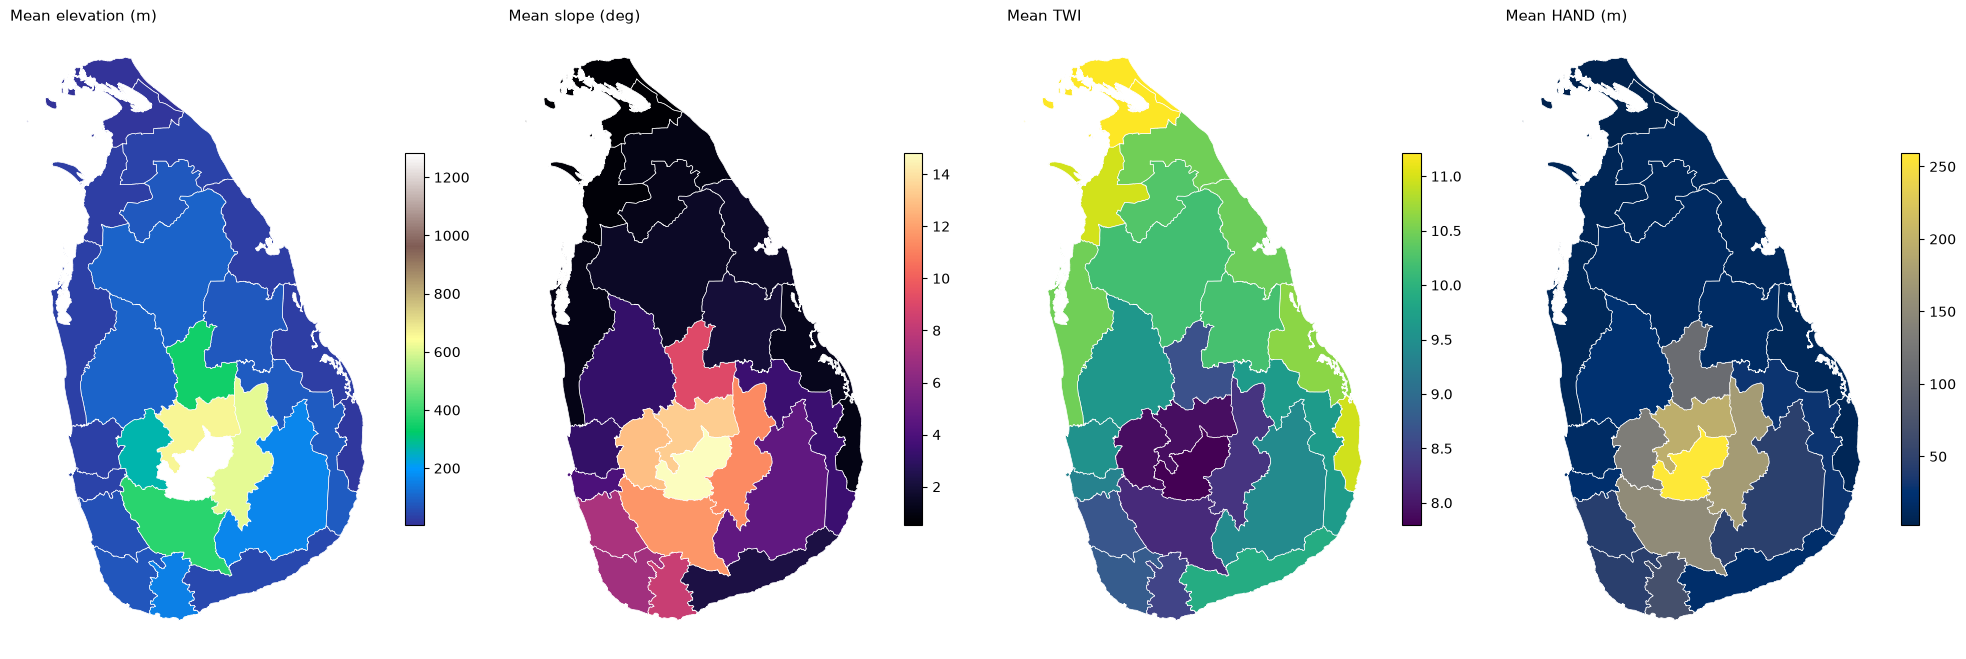

In [16]:
g = rdhs_ea.set_index("rdhs_id").join(feat.drop(columns="rdhs_name"))

fig, axes = plt.subplots(1, 4, figsize=(20, 6.5))
for ax, (col, label, cmap) in zip(axes, [
        ("elev_mean",  "Mean elevation (m)", "terrain"),
        ("slope_mean", "Mean slope (deg)",   "magma"),
        ("twi_mean",   "Mean TWI",           "viridis"),
        ("hand_mean",  "Mean HAND (m)",      "cividis")]):
    g.plot(column=col, ax=ax, cmap=cmap, edgecolor="white", linewidth=0.5,
           legend=True, legend_kwds={"shrink": 0.6})
    ax.set_title(label, loc="left", fontsize=11); ax.set_axis_off()
plt.tight_layout(); plt.show()

### Collinearity

TWI is built *from* slope, so they are related by construction. Worth seeing how much of the
batch-A block is redundant before it reaches a model — the plan warns that importance is unstable
under collinear geospatial factors.

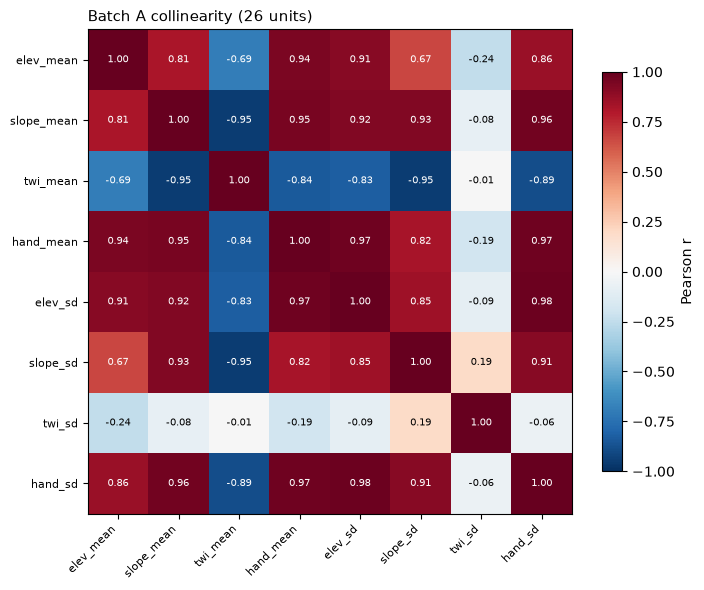

pairs with |r| > 0.8:
   elev_sd      hand_sd      +0.979
   hand_mean    elev_sd      +0.970
   hand_mean    hand_sd      +0.970
   slope_mean   hand_sd      +0.964
   slope_mean   twi_mean     -0.951
   twi_mean     slope_sd     -0.949
   slope_mean   hand_mean    +0.947
   elev_mean    hand_mean    +0.945
   slope_mean   slope_sd     +0.927
   slope_mean   elev_sd      +0.922
   slope_sd     hand_sd      +0.912
   elev_mean    elev_sd      +0.907
   twi_mean     hand_sd      -0.887
   elev_mean    hand_sd      +0.861
   elev_sd      slope_sd     +0.848
   twi_mean     hand_mean    -0.838
   twi_mean     elev_sd      -0.827
   hand_mean    slope_sd     +0.821
   elev_mean    slope_mean   +0.814


In [17]:
cols = ["elev_mean", "slope_mean", "twi_mean", "hand_mean",
        "elev_sd", "slope_sd", "twi_sd", "hand_sd"]
corr = feat[cols].corr()

fig, ax = plt.subplots(figsize=(7.2, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols, fontsize=8)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center",
                fontsize=7, color="white" if abs(corr.iloc[i,j]) > 0.55 else "black")
plt.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
ax.set_title("Batch A collinearity (26 units)", loc="left", fontsize=11)
plt.tight_layout(); plt.show()

hi_pairs = [(cols[i], cols[j], corr.iloc[i,j])
            for i in range(len(cols)) for j in range(i+1, len(cols))
            if abs(corr.iloc[i,j]) > 0.8]
print("pairs with |r| > 0.8:")
for a, b, r in sorted(hi_pairs, key=lambda t: -abs(t[2])):
    print(f"   {a:<12} {b:<12} {r:+.3f}")

## 11 · Freeze

Write the feature table to quarantine (gitignored — features are never committed) with a
provenance record naming the exact DEM tiles and parameters that produced it.

In [18]:
out_csv = QUAR / "m6_batchA_terrain_srilanka.csv"
feat.to_csv(out_csv)

prov = {
    "notebook": "01_terrain_batchA",
    "country": "sri_lanka",
    "n_units": int(len(feat)),
    "n_features": int(feat.shape[1] - 1),
    "target_res_m": TARGET_RES_M,
    "drainage_threshold_cells": DRAIN_THRESH,
    "crs_equal_area": CRS_EQUAL_AREA,
    "dem_source": "Copernicus GLO-30 (AWS Open Data, anonymous)",
    "dem_tiles": [tile_name(la, lo) for la, lo in tiles],
    "dem_tile_count": len(tiles),
    "geometry_sha256_16": prov0["geometry_sha256_16"],
    "output_sha256_16": hashlib.sha256(out_csv.read_bytes()).hexdigest()[:16],
}
(QUAR / "nb01_provenance.json").write_text(json.dumps(prov, indent=2))

print(json.dumps(prov, indent=2))
print("\nwritten:", out_csv)

{
  "notebook": "01_terrain_batchA",
  "country": "sri_lanka",
  "n_units": 26,
  "n_features": 21,
  "target_res_m": 90,
  "drainage_threshold_cells": 1000,
  "crs_equal_area": "+proj=laea +lat_0=7.6221 +lon_0=80.6987 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs",
  "dem_source": "Copernicus GLO-30 (AWS Open Data, anonymous)",
  "dem_tiles": [
    "Copernicus_DSM_COG_10_N05_00_E080_00_DEM",
    "Copernicus_DSM_COG_10_N06_00_E079_00_DEM",
    "Copernicus_DSM_COG_10_N06_00_E080_00_DEM",
    "Copernicus_DSM_COG_10_N06_00_E081_00_DEM",
    "Copernicus_DSM_COG_10_N07_00_E079_00_DEM",
    "Copernicus_DSM_COG_10_N07_00_E080_00_DEM",
    "Copernicus_DSM_COG_10_N07_00_E081_00_DEM",
    "Copernicus_DSM_COG_10_N08_00_E079_00_DEM",
    "Copernicus_DSM_COG_10_N08_00_E080_00_DEM",
    "Copernicus_DSM_COG_10_N08_00_E081_00_DEM",
    "Copernicus_DSM_COG_10_N09_00_E079_00_DEM",
    "Copernicus_DSM_COG_10_N09_00_E080_00_DEM"
  ],
  "dem_tile_count": 12,
  "geometry_sha256_16": "9e5e2c0a541ecac1",
  "ou

## 12 · Recap

In [19]:
recap = pd.DataFrame([
    ("DEM tiles downloaded",     len(tiles),                    "12 of 15 (3 are ocean)"),
    ("working resolution (m)",   TARGET_RES_M,                  "30 m native, resampled"),
    ("grid pixels (M)",          round(dem.size/1e6, 1),        ""),
    ("land pixels (M)",          round(land.sum()/1e6, 2),      ""),
    ("max elevation (m)",        round(float(np.nanmax(dem_land))), "Pidurutalagala 2,524"),
    ("analytic units",           len(feat),                     "26 RDHS"),
    ("features produced",        feat.shape[1]-1,               "4 layers x 5 stats + n_px"),
], columns=["quantity", "value", "reference"])
print(recap.to_string(index=False))
print()
print(feat[["rdhs_name","elev_mean","slope_mean","twi_mean","hand_mean"]]
      .sort_values("elev_mean", ascending=False).head(8).round(2).to_string())

              quantity   value                 reference
  DEM tiles downloaded   12.00    12 of 15 (3 are ocean)
working resolution (m)   90.00    30 m native, resampled
       grid pixels (M)   14.80                          
       land pixels (M)    8.15                          
     max elevation (m) 2514.00      Pidurutalagala 2,524
        analytic units   26.00                   26 RDHS
     features produced   21.00 4 layers x 5 stats + n_px

            rdhs_name  elev_mean  slope_mean  twi_mean  hand_mean
rdhs_id                                                          
RDHS_06  Nuwara Eliya    1283.32       14.81      7.80     259.31
RDHS_04         Kandy     660.87       13.35      7.92     197.07
RDHS_21       Badulla     612.70       11.34      8.32     172.18
RDHS_23     Ratnapura     376.10       11.68      8.21     151.99
RDHS_05        Matale     347.31        9.11      8.64     109.37
RDHS_24       Kegalle     267.28       12.86      7.90     133.02
RDHS_22    Mone

---

### What is established

Batch A complete: **elevation, slope, TWI, HAND** for all 26 RDHS units, each with mean, SD and
10th/50th/90th percentiles, derived from anonymously-downloaded Copernicus GLO-30 with no API key
and no account.

### Carry forward — these are static

All four vary across districts and **never across weeks**. A model built from batch A alone emits
one constant prediction per district for the entire study period. Against a weekly
elevated-activity label it can express *which* districts differ but never *when*, so it would
score near chance **by construction** — a structural null, not an empirical finding, and it must
not be reported as "geomatics carries no signal".

Notebook 02 adds the dynamic remotely-sensed layers (MODIS LST, NDVI/EVI, surface-water extent)
that give M6 genuine temporal signal. Those are what make this a real test.